In [1]:
from rabtracks import *
sns.set_context("paper")

In [50]:
def merge_legends(axs, syclops_axs):
    legend_dict = {}
    for i in syclops_axs: 
        HL = axs[i].get_legend_handles_labels()
        legend_dict = legend_dict | {HL[1][i]:HL[0][i] for i in range(len(HL[0]))}
    return legend_dict.values(), legend_dict.keys()

In [2]:
def plot_categorical(ax, time, values, color_map=labels_colors, hatch_map=labels_hatches, alpha=0.5):
    """
    Parameters
    ----------
    ax : matplotlib axes
    time : array of datetime values
    values : array of categorical labels (e.g., ["TC", "ETC", "TC", ...])
    color_map : dict mapping each label to a color, e.g. {"TC": "red", "ETC": "dodgerblue"}
    hatch_map : dict mapping each label to a hatch pattern (optional), e.g. {"TC": "//", "ETC": ".."}
    alpha : float
    """
    time = time - np.timedelta64(3, 'h')
    if hatch_map is None:
        hatch_map = {}

    seen_labels = set()

    for label, color in color_map.items():
        mask = (values == label).astype(int)
        diff = np.diff(mask, prepend=0, append=0)
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]

        for i, (s, e) in enumerate(zip(starts, ends)):
            ax.axvspan(time[s], time[min(e, len(time)-1)],
                       facecolor=color, alpha=alpha,
                       hatch=hatch_map.get(label, ''),
                       edgecolor='black',
                       label=label if label not in seen_labels else None)
            seen_labels.add(label)

    ax.set_yticks([])

In [55]:
def plot_nature(TRACK):
    fig, axs = plt.subplots(5, sharex = True, figsize = cm2inch([10,9]),)
    
    # IBTrACS nature
    plot_categorical(axs[0], TRACK.time.values, TRACK.nature.values,)
    axs[0].set_title("a) IBTrACS nature", style = "italic", size = "medium")
    #axs[0].set_ylabel("IBTrACS labels")#, rotation = 0, labelpad = 40, loc = "bottom")
    #axs[0].yaxis.set_label_coords(0.01, -1)
    
    # USA status
    plot_categorical(axs[1], TRACK.time.values, TRACK.usa_status.values,
                    color_map = {"TD":"gold", "TS":"orange", "HU":"red", "EX":"dodgerblue"}, 
                    hatch_map = {"TD":"/", "TS":"//", "HU":"///", "EX":"."})
    axs[1].set_title("b) IBTrACS USA Status", style = "italic", size = "medium")
    #axs[1].set_ylabel("IBTrACS\nusa_status")

    # SyCLoPS label
    A = "cde"
    syclops_axs = []
    for i, s in enumerate([s.values for s in TRACK.source if s.str.startswith("SyCLoPS")]):
        plot_categorical(axs[2+i], TRACK.time.values, TRACK.sel(source = s).label.astype(str).values)
        axs[2+i].set_title(A[i]+') '+s + " label", style = "italic", size = "medium")
        syclops_axs.append(2+i)
    #axs[3].set_ylabel("SyCLoPS labels", size = "medium")
    
    for ax in axs:
        ax.set_xlabel('')
        ax.grid()
        
    axs[-1].xaxis.set_major_formatter(DateFormatter('%d'))
    axs[-1].set_xlabel("Sept. 2020", loc = "right")
    
    NAME = TRACK.name.values[0]
    SEASON = TRACK.time.dt.year.values[0]
    fig.suptitle(NAME + ' ('+str(SEASON)+')')
    plt.tight_layout()
    fig.legend(*axs[0].get_legend_handles_labels(), title = "nature\nlabels",
               loc = "outside upper left", ncol = 1, bbox_to_anchor = (0.,0.03), frameon= False)
    fig.legend(*axs[1].get_legend_handles_labels(), title = "USA status\nlabels",
               loc = "outside upper left", ncol = 1, bbox_to_anchor = (0.155, 0.03), frameon= False)
    fig.legend(*merge_legends(axs, syclops_axs), title = "SyCLoPS labels",
               loc = "outside upper right", ncol = 2, bbox_to_anchor = (1.003, 0.03), frameon= False)
    print(merge_legends(axs, syclops_axs)[1])

    # Draw box with separators around all legend blocks
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    leg1_bbox = fig.legends[0].get_window_extent(renderer).transformed(fig.transFigure.inverted())
    leg2_bbox = fig.legends[1].get_window_extent(renderer).transformed(fig.transFigure.inverted())
    leg3_bbox = fig.legends[2].get_window_extent(renderer).transformed(fig.transFigure.inverted())

    all_bboxes = [leg1_bbox, leg2_bbox, leg3_bbox]
    x0 = min(b.x0 for b in all_bboxes)
    x1 = max(b.x1 for b in all_bboxes)
    y0 = min(b.y0 for b in all_bboxes)
    y1 = max(b.y1 for b in all_bboxes)

    pad = 0.005
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch((x0 - pad, y0 - pad), (x1 - x0) + 2 * pad, (y1 - y0) + 2 * pad,
                         transform=fig.transFigure, boxstyle="round,pad=0",
                         edgecolor='grey', facecolor='none', linewidth=0.8, clip_on=False)
    fig.add_artist(box)

    # Internal vertical separators
    for left, right in [(leg1_bbox, leg2_bbox), (leg2_bbox, leg3_bbox)]:
        x = (left.x1 + right.x0) / 2
        fig.add_artist(plt.Line2D([x, x], [y0 - pad, y1 + pad], transform=fig.transFigure,
                                  color='grey', linewidth=0.8, clip_on=False))

dict_keys(['EX', 'SC', 'SS(STLC)', 'PL(PTLC)', 'HTC', 'TC', 'TD', 'TLO', 'HATHL'])


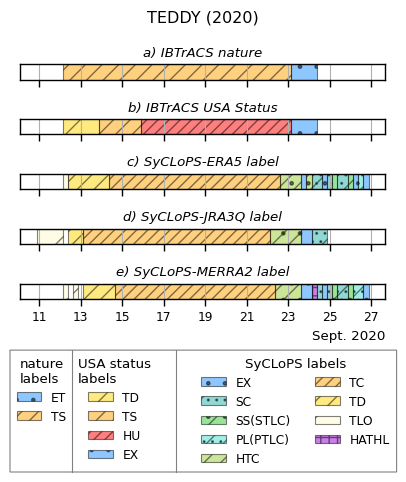

In [56]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
NAME, SEASON = "TEDDY", 2020
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_nature(TRACK)

plt.savefig("nature_info.png", bbox_inches = "tight")
plt.savefig("nature_info.pdf", bbox_inches = "tight")

dict_keys(['DSE', 'EX', 'SS(STLC)', 'TC', 'TD', 'TLO', 'DST', 'HAL', 'HATHL'])


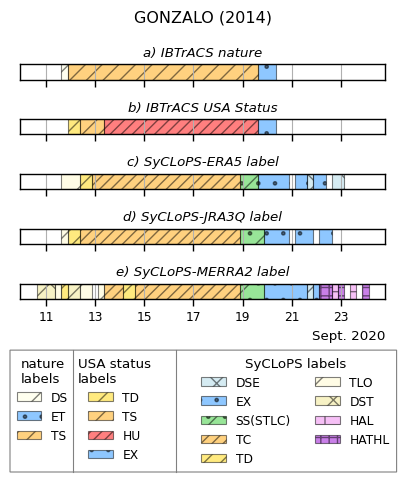

In [57]:
b = "NA"
eib = xr.open_dataset("../RABTracks/RABTracks_"+b+".nc")
NAME, SEASON = "GONZALO", 2014
TRACK = eib.where((eib.name == NAME) & (eib.time.dt.year == SEASON), drop = True)
TRACK = TRACK.set_coords("time").swap_dims({"record":"time"})
plot_nature(TRACK)

#plt.savefig("nature_info.png", bbox_inches = "tight")
#plt.savefig("nature_info.pdf", bbox_inches = "tight")

['' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' '' ''
 '' '' '' '' '' 'DST' 'DST' 'DST' 'TLO' 'TD' 'DST' 'DST' 'TLO' 'TLO' ''
 'TLO' 'TC' 'TC' 'TC' 'TD' 'TD' 'TC' 'TC' 'TC' 'TC' 'TC' 'TC' 'TC' 'TC'
 'TC' 'TC' 'TC' 'TC' 'TC' 'TC' 'TC' 'TC' 'TC' 'SS(STLC)' 'SS(STLC)'
 'SS(STLC)' 'SS(STLC)' 'EX' 'EX' 'EX' 'EX' 'EX' 'EX' 'EX' 'DSE' 'EX'
 'HATHL' 'HATHL' 'HAL' 'HATHL' '' 'HAL' '' 'HATHL' '' '' '' '' '' '' '' ''
 '' '' '' '' '']


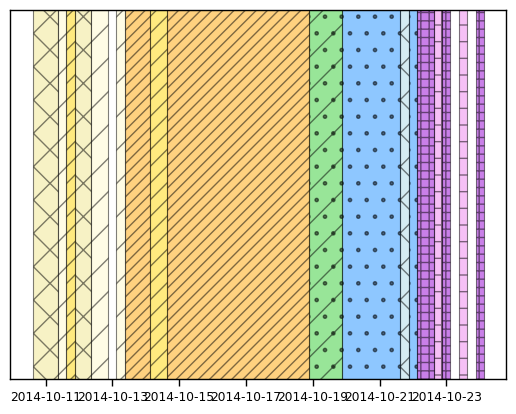

In [6]:
ax = plt.axes()
#plot_categorical(axs[2+i], TRACK.time.values, TRACK.sel(source = s).label.astype(str).values)
labs = TRACK.sel(source = "SyCLoPS-MERRA2").label.astype(str).values
print(labs)
plot_categorical(ax, TRACK.time.values, labs)

In [7]:
TRACK.sel(source = "SyCLoPS-MERRA2").label.astype(str).values

array(['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '',
       '', '', '', '', '', '', '', '', '', '', '', '', 'DST', 'DST',
       'DST', 'TLO', 'TD', 'DST', 'DST', 'TLO', 'TLO', '', 'TLO', 'TC',
       'TC', 'TC', 'TD', 'TD', 'TC', 'TC', 'TC', 'TC', 'TC', 'TC', 'TC',
       'TC', 'TC', 'TC', 'TC', 'TC', 'TC', 'TC', 'TC', 'TC', 'TC',
       'SS(STLC)', 'SS(STLC)', 'SS(STLC)', 'SS(STLC)', 'EX', 'EX', 'EX',
       'EX', 'EX', 'EX', 'EX', 'DSE', 'EX', 'HATHL', 'HATHL', 'HAL',
       'HATHL', '', 'HAL', '', 'HATHL', '', '', '', '', '', '', '', '',
       '', '', '', '', ''], dtype='<U8')